In [84]:
import pandas as pd

df = pd.read_csv("done_labeling_2500_lr.csv")
df.head()

,processed_text,sentiment
0,duitnya dipake buat tahun baruan hidup korupto...,negatif
1,jangan sebut tanggapan misbahun bin satan angg...,negatif
2,beh indonesia negri birokrasi pasien mau berob...,positif
3,guys nurunin inflasi itu tak mudah guys pak pu...,netral
4,indondesh banyak pakai pemimpin bodoh,negatif


In [85]:
df_full = pd.read_csv("full_labeling.csv")

labeled_text = set(
    df["processed_text"]
)

unlabeled_df = df_full[
    ~df_full["processed_text"]
    .isin(labeled_text)
]

In [86]:
print(len(df))
print(len(df_full))
print(len(unlabeled_df))

2500
18093
15685


In [87]:
label_map = {
    "negatif":0,
    "positif":1,
    "netral":2,

}

df["label"] = df["sentiment"].map(label_map)

In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X = vectorizer.fit_transform(df["processed_text"])

y = df["label"]

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

from sklearn.svm import LinearSVC

model_lr = LinearSVC()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [90]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
    )
)

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       312
           1       0.73      0.66      0.70       121
           2       0.80      0.79      0.80       192

    accuracy                           0.81       625
   macro avg       0.79      0.77      0.78       625
weighted avg       0.80      0.81      0.80       625



In [91]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=[
            "negatif",
            "positf",
            "netral"
        ]
    )
)

              precision    recall  f1-score   support

     negatif       0.83      0.87      0.85       312
      positf       0.73      0.66      0.70       121
      netral       0.80      0.79      0.80       192

    accuracy                           0.81       625
   macro avg       0.79      0.77      0.78       625
weighted avg       0.80      0.81      0.80       625



<Axes: >

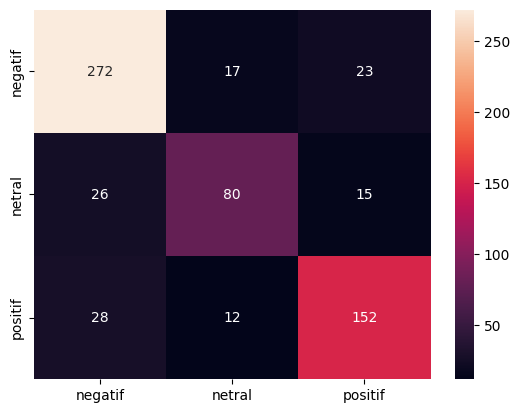

In [92]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(
    y_test,
    y_pred_lr
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["negatif", "netral", "positif"],
    yticklabels=["negatif", "netral", "positif"]

)

<Axes: >

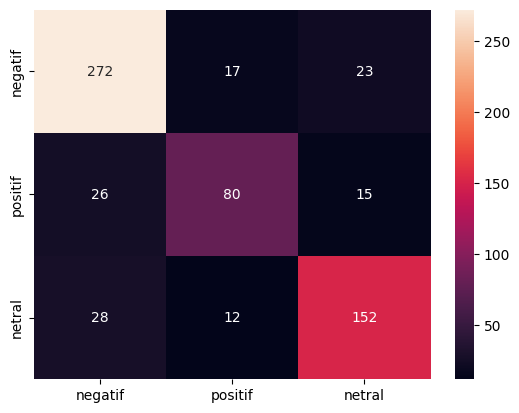

In [93]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(
    y_test,
    y_pred_lr   
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["negatif", "positif", "netral"],
    yticklabels=["negatif", "positif", "netral"]

)

In [94]:
X_unlabeled = vectorizer.transform(
    unlabeled_df['processed_text']
)

predictions = model_lr.predict(
    X_unlabeled
)

reverse_map = {
    0: "negatif",
    1: "netral",
    2: "positif"
}

unlabeled_df["sentiment"] = [
    reverse_map[x]
    for x in predictions
]

print(
    unlabeled_df["sentiment"].value_counts()
)

sentiment
negatif    8641
positif    4490
netral     2554
Name: count, dtype: int64


In [95]:
unlabeled_df.to_csv(
    "done_labeling_15k_lr.csv",
    index=False
)

In [96]:
df_merge = pd.concat(
    [
        df[["processed_text", "sentiment"]],
        unlabeled_df[["processed_text", "sentiment"]]
    ],
    ignore_index=True
)

print(
    df_merge["sentiment"].value_counts()
)

sentiment
negatif    9890
positif    4972
netral     3323
Name: count, dtype: int64


In [97]:
df_merge.to_csv(
    "18k_done_sentiment_lr.csv",
    index=False
)

CLOUDWORD

In [98]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X_neg = cv.fit_transform(
    df_merge[df_merge["sentiment"]=="negatif"]["processed_text"]
    )

neg_freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X_neg.sum(axis=0).A1
})

neg_freq.sort_values("freq", ascending=False).head(50)



,word,freq
19832,yang,5636
18744,tidak,4990
4003,di,3812
3755,dan,3431
10246,makan,2381
6388,gratis,2151
7198,ini,2111
2210,bergizi,1988
12683,negara,1982
7413,itu,1964


In [99]:
custom_stopwords = [
    "yang",
    "tidak",
    "di",
    "dan",
    "ini",
    "itu",
    "sudah",
    "saja",
    "dari",
    "kalau",
    "ada",
    "bisa",
    "tapi",
    "nya",
    "ke",
    "jadi",
    "karena",
    "lagi",
    "naik",
    "dengan",
    "untuk",
    "akan",
    "semua",
    "sama",
    "juga",
    "lebih",
    "lain",
    "pada",
    "masih",
    "ya",
    "apa",
    "saya",
    "mau"
]

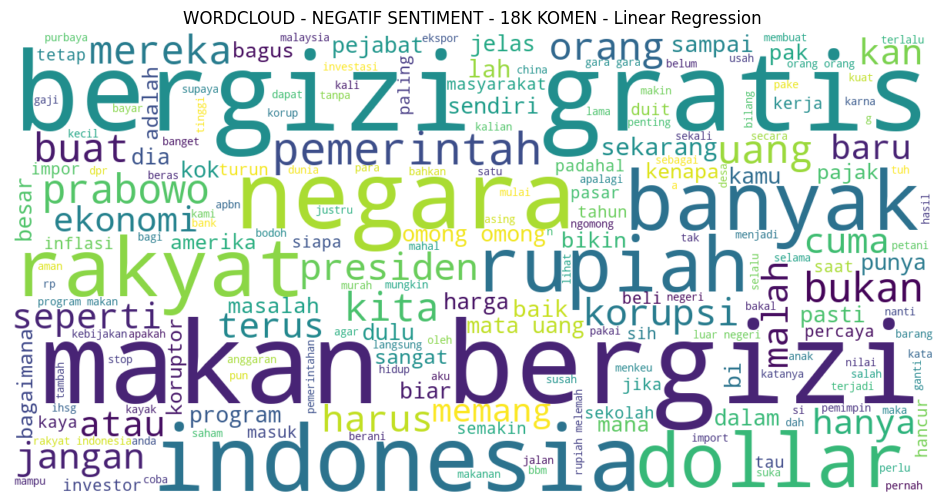

In [100]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

negatif_text = " ".join(
    df_merge[df_merge["sentiment"]== 'negatif']["processed_text"]

)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords
).generate(negatif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WORDCLOUD - NEGATIF SENTIMENT - 18K KOMEN - Linear Regression")
plt.show()

In [101]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X_pos = cv.fit_transform(
    df_merge[df_merge["sentiment"]=="positif"]["processed_text"]
    )

pos_freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X_pos.sum(axis=0).A1
})

pos_freq.sort_values("freq", ascending=False).head(50)



,word,freq
12558,yang,1477
2826,di,1094
11782,tidak,911
2640,dan,744
10173,saja,650
4775,indonesia,639
8479,orang,577
521,ada,543
8289,nya,540
866,apa,536


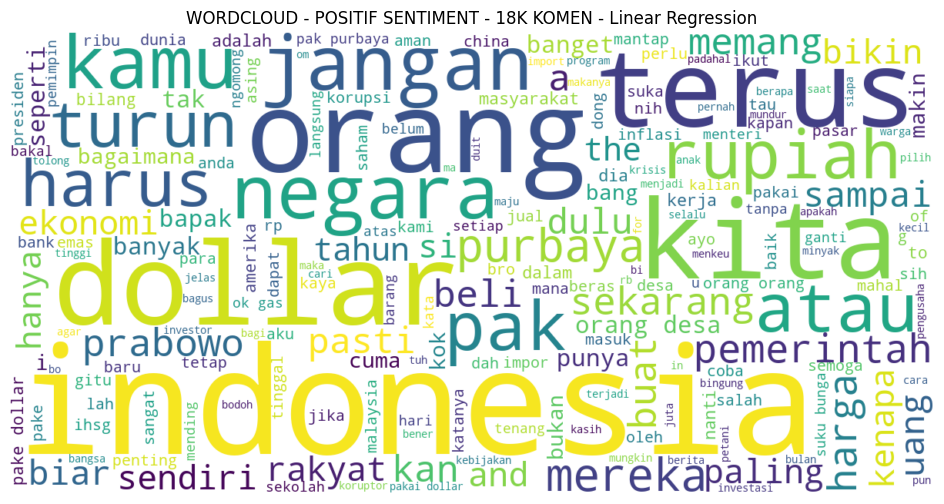

In [102]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positif_text = " ".join(
    df_merge[df_merge["sentiment"]== 'positif']["processed_text"]

)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords
).generate(positif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WORDCLOUD - POSITIF SENTIMENT - 18K KOMEN - Linear Regression")
plt.show()